# Compute the global time series

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/home/b/b384080/.conda/envs/eekenv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 0) define functions

In [2]:
def calc_vertical_stat(da, thickness_weights, stat, mask=None, dims=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_vertical_mean(da, thickness_weights, mask=mask, dims=dims)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_vertical_integral(da, thickness_weights, mask=mask, dims=dims)
    return da_stat

def calc_horizontal_stat(da, area_weights, stat, mask=None, dims=None,grid_cell_fractions=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_spatial_mean(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_spatial_integral(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
    return da_stat

def get_stat(varia,model):

    # default settings
    if varia in ['tas','tos','chlos','co2s','co2','zos','no3os','o2','no3']:
        stat = 'mean'
    elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cSoilFast','cSoilMedium','cSoilSlow','cVeg','cCwd','cLitter','dissic','fco2antt','intdic','epc100']:
        stat = 'integral'
    elif varia in ['co2mass','zostoga']:
        stat = None

    # overwrite some choices
    if model == 'GISSE2.1-G-CC2':
        if varia == 'co2mass':
            stat = 'integral'

    # overwrite some choices
    if model == 'EC-Earth3-ESM-1':
        if varia == 'co2s':
            stat = None   
    
    return stat

def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        elif varia in ['co2','o2','no3']:
            vert_stat = 'mean'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat

## 1) get the varias, models and runs over which to do computation

In [3]:
#stat = 'integral'#'mean'
freq_input = 'monthly' #'monthly'#'yearly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = [
    #'cCwd',
    #'cLand',
    #'cLitter',
    #'co2',
    #'co2s',
    #'co2mass',
    #'cSoil',
    #'cVeg',
    #'dissic',
    #'epc100',
    #'fco2antt',
    #'fgco2',
    #'intdic',
    #'intpp',
    #'nbp',
    #'npp',
    'no3',
    #'o2',
    #'tas',
    #'tos',
    #'zos',
    #'zostoga',
    ]#]#['fco2antt']#['fgco2']#[['fgco2','intpp','epc100','tas','nbp','npp','cLand','cSoil','cVeg','co2mass','fco2antt']#  'cCwd','cLitter','tos',                     'intdic' # ]#,'tas','npp','cSoil',,'nbp']#['tas']#['cSoil','cVeg']##['tas']#['siconc','hfds','epc100','mlotst']#['cVeg','cLand','co2mass'] # 'tas','tos','fgco2','nbp','intpp','npp','intdic','cSoil', #['dissic']#['cLand','cSoil','cVeg','co2mass','fco2antt']##['npp','nbp','cSoil','cVeg','cLand','co2mass']#['tas','tos','fgco2','intpp','intdic',]#['intpp','intdic']##['tas','npp','nbp','cSoil','cVeg','cLand','co2mass','intdic','intpp','tos','fgco2'] #'co2mass']#,'fco2antt']#,'intdic'] #['dissic']#['intpp','npp','tas','tos','fgco2','nbp','fco2antt','cLand','cVeg','cSoil','npp','co2mass',]#['co2']#['co2mass']#['cSoilFast','cSoilMedium','cSoilSlow']#['epc100','cLand','cVeg','nbp','intpp','npp']#,'fgco2',''epc100']#['epc100','fgco2','intpp','tos']#['npp','cSoil','cLand','cVeg']#['fgco2','tas']#['epc100']#['fgco2','intpp','npp','cLand']#['co2s']#['intpp','chlos','epc100']#['cLand','cVeg','cSoil','npp','co2mass','tas','tos','fgco2','nbp','fco2antt','intpp','npp','cLand','cVeg','cSoil','intdic']#['npp','cLand','fgco2','nbp','fco2antt']#'fco2antt']#['tas','nbp','fgco2','fco2antt','co2mass','tos','npp']#]#['intpp','npp','tos'] # ['fgco2','nbp','cLand','dissic','cSoil','cVeg','cLitter','cCwd']#  # 'tas',                ,'co2mass']#['fgco2']#['nbp']#['nbp','cLand'] #['nbp']#['nbp']#['fco2antt']#['cLand','cSoil','cVeg','cLitter','cCwd']#['cLitter']#'cCwd',#['cLand']#['cSoil','cVeg']#['cLitter']#['cCwd']#['cSoil','cVeg']#'cLand',#['tas','nbp','npp','tos','fgco2','intpp']
models = ['CESM2']#['ACCESS-ESM1-5']#['CESM2']#['GISSE2.1-G-CC2']#['UKESM1-2']#['MIROC-ES2L']#['EC-Earth3-ESM-1']#['IPSL-CM6-ESMCO2']#['GFDL-ESM2M']#['NorESM2-LM']#['IPSL-CM6-ESMCO2']#['EC-Earth3-ESM-1']#['ACCESS-ESM1-5']#['MIROC-ES2L']##['EC-Earth3-ESM-1']#['EC-Earth3-ESM-1']#['CESM2']#['EC-Earth3-ESM-1']#['UKESM1-2']#['ACCESS-ESM1-5']#['GISSE2.1-G-CC2']#['CESM2']#['UKESM1-2']#['EC-Earth3-ESM-1']#,['EC-Earth3-ESM-1']#['UKESM1-2']#['MIROC-ES2L']##['ACCESS-ESM1-5']#['EC-Earth3-ESM-1'] #['CESM2']#['NorESM2-LM']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['CESM2']#['GISSE2.1-G-CC2']#['NorESM2-LM']#['CESM2']#['UKESM1-2']#['EC-Earth3-ESM-1']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']##['GISSE2.1-G-CC2']#['CESM2']#['ACCESS-ESM1-5'] #['ACCESS-ESM1-5']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M']#['MIROC-ES2L'] ['IPSL-CM6-ESMCO2']#['UKESM1-2']#['IPSL-CM6-ESMCO2']#['IPSL-CM6-ESMCO2']#[]#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1']#,'UKESM1-2']#['NorESM2-LM']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['UKESM1-2']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M'] # ,
runs = pruns.get_run_list('tipmip_tier1')[1:]#[3:]#[:3]#[3:4]#[:1]#[-1:]#[-2:]#[-2:]#[2:]#[-1:]#[:1]#[5:]#[1:]#[:-1]#[:1]#[-1:]#[:1]#[:1]#[1:]#[-1:] #

#server='spirit'#'levante'#'spirit'#
#outroot = './../01_postprocessed_data/global_time_series' # 04_processed_data
outroot = './../04_processed_data/global_time_series' # 04_processed_data

model_dict = pmods.get_model_dict('all')

choose_depth_slice_range = True
zmin = 0
zmax = 100
print(f'adapting thickness_weights for a particular depth range: {zmin}-{zmax}m')



adapting thickness_weights for a particular depth range: 0-100m


## 2) loop over models and runs to do the computation, plotting and saving

In [4]:
from dask.distributed import Client
client = Client(n_workers=4)
client

server = MISCgrabber.get_server()
if server == 'levante':
    port = client.scheduler_info()["services"]["dashboard"]
    prefix = os.environ.get("JUPYTERHUB_SERVICE_PREFIX", "/")
    proxy_url = f"https://jupyterhub.dkrz.de/{prefix}proxy/{port}/status"
    print(proxy_url)

working on server levante
https://jupyterhub.dkrz.de//user/b384080/levante-spawner-advanced/proxy/8787/status


2026-09-16 18:55:52,234 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:38177 (pid=2920088) exceeded 95% memory budget. Restarting...
2026-09-16 18:55:53,190 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:38177' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('rechunk-merge-3b2806022afa83a5f0e006624dddd240', 284, 0, 1, 1), ('rechunk-merge-3b2806022afa83a5f0e006624dddd240', 253, 0, 1, 1), ('rechunk-merge-3b2806022afa83a5f0e006624dddd240', 260, 0, 1, 1), ('open_dataset-concatenate-6aca38d1e64e7c708931603eba2f85a7', 2762, 0, 1, 1), ('rechunk-merge-3b2806022afa83a5f0e006624dddd240', 285, 0, 0, 0), ('rechunk-merge-3b2806022afa83a5f0e006624dddd240', 243, 0, 1, 1), ('rechunk-merge-3b2806022afa83a5f0e006624dddd240', 240, 0, 1, 1), ('open_dataset-concatenate-6aca38d1e64e7c708931603eba2f85a7', 2764, 1, 1, 1), ('rechunk-merge-3b2806022afa83a5f0e006624dddd240', 286, 0, 0, 1), 'original-open_dataset-NO3-2c07e72c86f6eed5a

In [5]:
def depth_fraction(da, zmin=100, zmax=600):
    """
    Fraction of each vertical cell within the depth range [zmin, zmax].

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with a 'z_t' dimension containing cell-center depths.
    zmin : float
        Upper depth boundary.
    zmax : float
        Lower depth boundary.

    Returns
    -------
    xarray.DataArray
        Fraction of each z_t cell lying within [zmin, zmax].
        Values range from 0 to 1.
    """

    z = da.z_t

    # Cell tops: midpoint between current and previous cell centers.
    z_top = (z + z.shift(z_t=1)) / 2
    z_top = z_top.fillna(0)

    # Cell bottoms: midpoint between current and next cell centers.
    z_bottom = (z + z.shift(z_t=-1)) / 2

    # Extrapolate the bottom boundary of the last cell.
    last_bottom = 2 * z[-1] - z[-2]
    z_bottom = z_bottom.fillna(last_bottom)
    z_bottom = z_bottom.where(z_bottom.notnull(), last_bottom)

    # Actual overlap with [zmin, zmax].
    overlap = xr.where(
        (z_bottom > zmin) & (z_top < zmax),
        np.minimum(z_bottom, zmax) - np.maximum(z_top, zmin),
        0
    )

    # Fraction of each cell inside the requested range.
    fraction = overlap / (z_bottom - z_top)

    return fraction.clip(0, 1)

no3
NO3
Processing data for NO3, CESM2, esm-up2p0...
['/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0.001.pop.h.NO3.000101-001012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0.001.pop.h.NO3.001101-002012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0.001.pop.h.NO3.002101-003012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0.001.pop.h.NO3.003101-004012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0.001.pop.h.NO3.004101-005012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0.001.pop.h.NO3.005101-006012.nc', '/work/bm1

/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/home/b/b384

<xarray.DataArray 'NO3' (time: 3000, z_t: 60, nlat: 384, nlon: 320)> Size: 88GB
dask.array<concatenate, shape=(3000, 60, 384, 320), dtype=float32, chunksize=(1, 30, 192, 160), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 24kB 0001-02-01 00:00:00 ... 0251-01-01 00:00:00
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Dissolved Inorganic Nitrate
    units:         mmol/m^3
    grid_loc:      3111
    cell_methods:  time: mean
... loading 3000 data points in time.
<xarray.DataArray 'time' (time: 3000)> Size: 24kB


/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/home/b/b384

<xarray.DataArray 'thkcello' (z_t: 60, nlat: 384, nlon: 320)> Size: 59MB
dask.array<truediv, shape=(60, 384, 320), dtype=float64, chunksize=(60, 384, 320), chunktype=numpy.ndarray>
Coordinates:
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:  thickness of layer k
    units:      m
... compute vertical statistic
<xarray.DataArray 'NO3' (time: 3000, z_t: 60, nlat: 384, nlon: 320)> Size: 88GB
dask.array<rechunk-merge, shape=(3000, 60, 384, 320), dtype=float32, chunksize=(12, 60, 192, 160), chunktype=numpy.ndarray>
Coordinates:
  * time  

...

<xarray.DataArray 'NO3' (time: 3648, z_t: 60, nlat: 384, nlon: 320)> Size: 108GB
dask.array<concatenate, shape=(3648, 60, 384, 320), dtype=float32, chunksize=(1, 30, 192, 160), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 29kB 0406-02-01 00:00:00 ... 0710-01-01 00:00:00
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Dissolved Inorganic Nitrate
    units:         mmol/m^3
    grid_loc:      3111
    cell_methods:  time: mean
... loading 3648 data points in time.
<xarray.DataArray 'time' (time: 3648)> Size: 29kB

/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/home/b/b384

<xarray.DataArray 'thkcello' (z_t: 60, nlat: 384, nlon: 320)> Size: 59MB
dask.array<truediv, shape=(60, 384, 320), dtype=float64, chunksize=(60, 384, 320), chunktype=numpy.ndarray>
Coordinates:
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:  thickness of layer k
    units:      m
... compute vertical statistic
<xarray.DataArray 'NO3' (time: 3648, z_t: 60, nlat: 384, nlon: 320)> Size: 108GB
dask.array<rechunk-merge, shape=(3648, 60, 384, 320), dtype=float32, chunksize=(12, 60, 192, 160), chunktype=numpy.ndarray>
Coordinates:
  * time 

2026-09-16 19:30:55,885 - distributed.worker.memory - WARNING - Worker is at 82% memory usage. Pausing worker.  Process memory: 20.51 GiB -- Worker memory limit: 25.00 GiB
2026-09-16 19:30:55,960 - distributed.worker.memory - WARNING - Worker is at 79% memory usage. Resuming worker. Process memory: 19.87 GiB -- Worker memory limit: 25.00 GiB
2026-09-16 19:30:56,476 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  Process memory: 20.91 GiB -- Worker memory limit: 25.00 GiB
2026-09-16 19:30:56,846 - distributed.worker.memory - WARNING - Worker is at 75% memory usage. Resuming worker. Process memory: 18.92 GiB -- Worker memory limit: 25.00 GiB
2026-09-16 19:30:57,368 - distributed.worker.memory - WARNING - Worker is at 84% memory usage. Pausing worker.  Process memory: 21.02 GiB -- Worker memory limit: 25.00 GiB
2026-09-16 19:30:58,904 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:35455
Traceback (most recent

... getting area weights.
getting land area fraction if necessary
... compute horizontal statistic
<xarray.DataArray 'time' (time: 3648)> Size: 29kB
array([cftime.DatetimeNoLeap(406, 1, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(406, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(406, 3, 15, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(709, 10, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(709, 11, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(709, 12, 15, 0, 0, 0, 0, has_year_zero=True)],
      shape=(3648,), dtype=object)
Coordinates:
  * time     (time) object 29kB 0406-01-15 00:00:00 ... 0709-12-15 00:00:00
<xarray.DataArray (time: 3648)> Size: 29kB
array([4.51819007, 4.58286091, 4.64150211, ..., 5.16765558, 4.97025804,
       4.84476101], shape=(3648,))
Coordinates:
  * time     (time) object 29kB 0406-01-15 00:00:00 ... 0709-12-15 00:00:00
Attributes:
    long_name:     vert

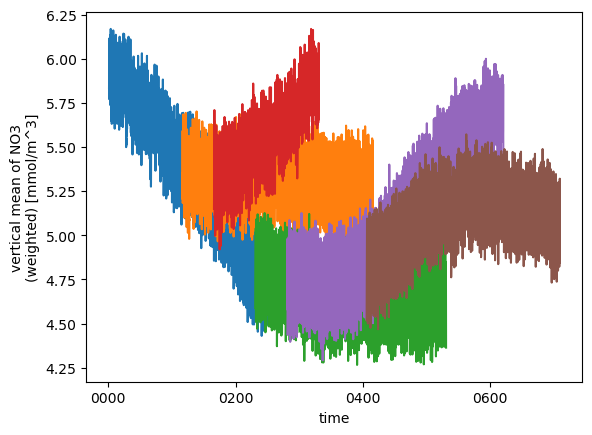

In [6]:
for varia in varias:
    for model in models:
        mgrab = MODELgrabber.get_grabber(model)
        stat = get_stat(varia,model)
        vert_stat = get_vert_stat(varia,default=True)

        global_stats = dict()
        for run in runs:

            if model == 'GISSE2.1-G-CC2':
                member = mgrab.get_member(run)
            else:
                member = mgrab.get_member()

            if model == 'CESM2':
                print(varia)
                varia = mgrab.varia_mapper_cmor_to_model(varia)
                print(varia)

            if model == 'GISSE2.1-G-CC2':
                domain = mgrab.get_domain(varia,freq_input,run)
            else:
                domain = mgrab.get_domain(varia,freq_input)
        
            print(f'Processing data for {varia}, {model}, {run}...')
            
            # first get the dataset
            da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=1)   #,server=server)#,server=server)
            print(f'... loading {da.time.size} data points in time.')

            if model == 'CESM2' and varia == 'TEMP':
                print('choosing only the shallowest layer')
                da = da.isel(z_t=0)#.squeeze().persist()
                #print(da)

            print(da.time)
            # =====================================================
            # OPTIONAL VERTICAL STAT
            # =====================================================
            if vert_stat is not None:
                print(domain)
                print(da.dims)
                if domain in ['O','OP','OB','ocn']:
                    if "lev" in da.dims:
                        da = da.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
                    elif "olevel" in da.dims:
                        da = da.chunk({"time": 12,"olevel": -1})#,"i": -1,"j": -1})
                    elif "z_t" in da.dims:
                        da = da.chunk({"time": 12,"z_t": -1})#,"i": -1,"j": -1})

                    print('... get thickness weights')
    
                    if model == 'NorESM2-LM':
                        thickness_weights = mgrab.get_thickness(
                            'thkcello',freq_input)
                        thickness_weights = thickness_weights.chunk({"lev": -1})#,"i": -1,"j": -1})
                    elif model == 'GFDL-ESM2M':
                        thickness_weights = mgrab.get_data(
                            'thkcello',run,freq_input=freq_input, verbose_level=0)
                        thickness_weights = thickness_weights.chunk({"time": 12, "olevel": -1})#,"i": -1,"j": -1})
                    elif model == 'CESM2':
                        thickness_weights = mgrab.get_dz(run,freq_input='monthly',verbose_level=1)
                        #print(thickness_weights.values)
                        #raise Exception('until here')
                        #thickness_weights = 
                    elif model == 'ACCESS-ESM1-5':
                        thickness_weights = mgrab.get_data(
                            'thkcello', run, freq_input='fx', verbose_level=1)
                        # give thickness_weights the same longitudes as in da (they differ by maximally 3.8e-06...)
                        thickness_weights = thickness_weights.assign_coords(longitude=da.longitude)
                        #thickness_weights = thickness_weights.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})                        
                    else:
                        thickness_weights = mgrab.get_data(
                            'thkcello', run, freq_input=freq_input, verbose_level=0)
                        thickness_weights = thickness_weights.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
                    #print(thickness_weights)
                elif domain in ['A','atm','AP']:
                    if model == 'CESM2':
                        preslev = 'lev'
                        da = da.chunk({"time": 12,'lev': -1})#,"i": -1,"j": -1})
                        lev = da['lev']  # [plev], in Pa
                        # Step 1: layer thickness from differences
                        dp = np.abs(lev.diff(dim='lev'))
                        # Step 2: append last value (reuse last plev)
                        first_lev = lev.isel(lev=0)
                        dp = xr.concat([first_lev,dp], dim='lev')
                        # Step 3: fix coordinate alignment
                        thickness_weights = dp.assign_coords(plev='lev')
                    elif model == 'GFDL-ESM2M':
                        preslev = 'plev19'
                        da = da.chunk({"time": 12,'plev19': -1})#,"i": -1,"j": -1})
                        plev19 = da['plev19']  # [plev], in Pa
                        # Step 1: layer thickness from differences
                        dp = np.abs(plev19.diff(dim='plev19'))
                        # Step 2: append last value (reuse last plev)
                        last_plev = plev19.isel(plev19=-1)
                        dp = xr.concat([dp, last_plev], dim='plev19')
                        # Step 3: fix coordinate alignment
                        thickness_weights = dp.reset_index("plev19").reset_coords("plev19", drop=True) # .assign_coords(plev19='plev19')
                    elif model in ['IPSL-CM6-ESMCO2']:
                        preslev = 'plev'
                        da = da.chunk({"time": 12,'plev': -1})#,"i": -1,"j": -1})
                        plev = da['plev']  # [plev], in Pa
                        # Step 1: layer thickness from differences
                        dp = np.abs(plev.diff(dim='plev'))
                        # Step 2: append last value (reuse last plev)
                        last_plev = plev.isel(plev=-1)
                        dp = xr.concat([dp, last_plev], dim='plev')
                        # Step 3: fix coordinate alignment
                        thickness_weights = dp.reset_index("plev").reset_coords("plev", drop=True)
                    elif model in ['NorESM2-LM'] and run == 'esm-piControl':
                        preslev = 'plev'
                        da = da.chunk({"time": 12,'plev': -1})#,"i": -1,"j": -1})
                        plev = da['plev']  # [plev], in Pa
                        # Step 1: layer thickness from differences
                        dp = np.abs(plev.diff(dim='plev'))
                        # Step 2: append last value (reuse last plev)
                        last_plev = plev.isel(plev=-1)
                        dp = xr.concat([dp, last_plev], dim='plev')
                        # Step 3: fix coordinate alignment
                        thickness_weights = dp.reset_index("plev").reset_coords("plev", drop=True)                  
                    elif model in ['NorESM2-LM'] and run != 'esm-piControl':
                        preslev = 'lev'
                        da = da.chunk({"time": 12,'lev': -1})#,"i": -1,"j": -1})
                        lev = da['lev']  # [plev], in Pa
                        # Step 1: layer thickness from differences
                        dp = np.abs(lev.diff(dim='lev'))
                        # Step 2: append last value (reuse last plev)
                        last_plev = lev.isel(lev=-1)
                        dp = xr.concat([dp, last_plev], dim='lev')
                        # Step 3: fix coordinate alignment
                        thickness_weights = dp.reset_index("lev").reset_coords("lev", drop=True)     
                    else:
                        preslev = 'plev'
                        da = da.chunk({"time": 12,'plev': -1})#,"i": -1,"j": -1})
                        plev = da['plev']  # [plev], in Pa
                        # Step 1: layer thickness from differences
                        dp = np.abs(plev.diff(dim='plev'))
                        # Step 2: append last value (reuse last plev)
                        last_plev = plev.isel(plev=-1)
                        dp = xr.concat([dp, last_plev], dim='plev')
                        # Step 3: fix coordinate alignment
                        thickness_weights = dp.assign_coords(plev='plev').reset_coords("plev", drop=True)
                    
                print('... compute vertical statistic')
                print(da)
                print(thickness_weights)
        
                if choose_depth_slice_range == True:
                    print(f'adapting thickness_weights for a particular depth range: {zmin}-{zmax}')
                    if model == 'CESM2':
                        zmin_dubb = zmin*100.
                        zmax_dubb = zmax*100.
                    else:
                        zmin_dubb = zmin
                        zmax_dubb = zmax                        
                    fraction = depth_fraction(da, zmin=zmin_dubb, zmax=zmax_dubb)
                    thickness_weights = thickness_weights*fraction  #mask_thickness_weights(thickness_weights,zmin=zmin,zmax=max)

                da_for_horiz = calc_vertical_stat(
                    da.squeeze(),
                    thickness_weights,
                    vert_stat,
                    mask=None,
                    dims=None,
                )
                da_for_horiz.name = f"{varia}_vertical_{vert_stat}"
                da_for_horiz = da_for_horiz.persist()
            else:
                da_for_horiz = da

            # =====================================================
            # HORIZONTAL STAT (on correct input)
            # =====================================================
            
            if stat is not None:
                # get the area_weights
                print(f'... getting area weights.')
                if model == 'GISSE2.1-G-CC2':
                    area_weights = mgrab.get_area(varia,freq_input,run)
                    print(area_weights)
                else:
                    area_weights = mgrab.get_area(varia,freq_input)
                #area_weights.plot();plt.show()
                #print(area_weights.lat)
                
                # which region do i want to cover
                #print(f'... getting a regional mask.') 
                
                #if varia in ['nbp','cLand']:
                print('getting land area fraction if necessary')
                grid_cell_fractions = mgrab.get_area_fraction(varia)
                #grid_cell_fractions.plot();plt.show()
                #print(grid_cell_fractions.lat)
                #else:
                #    grid_cell_fractions = None

                print('... compute horizontal statistic')
                global_stat = calc_horizontal_stat(
                    da_for_horiz,   # <-- key line
                    area_weights,
                    stat,
                    mask=None,
                    dims=None,
                    grid_cell_fractions=grid_cell_fractions,
                )
            else:
                grid_cell_fractions = mgrab.get_area_fraction(varia) # not directly used, but required for writing some attributes later on
                global_stat = da_for_horiz

            print(global_stat.time)
            # make sure that the time has uniform axis
            global_stat = TimeOperator.adjust_time_axis(global_stat,calendar=model_dict[model].calendar)
            print(global_stat)
            

            # =====================================================
            # NAMING (clean + consistent)
            # =====================================================
            if model == 'CESM2':
                print(varia)
                varia = mgrab.varia_mapper_model_to_cmor(varia)
                print(varia)

            name_parts = [varia]
            if vert_stat is not None:
                name_parts.append(f"vertical_{vert_stat}")
            name_parts.append(f"global_{stat}")
            namer =  "_".join(name_parts)
            global_stat.name = namer
            
            # update the unit
            if stat == 'integral' and vert_stat is None:
                unit = f'{da.units} x m2'
            elif stat == 'integral' and vert_stat == 'integral':
                unit = f'{da.units} x m x m2'
            elif stat == 'integral' and vert_stat == 'mean':
                unit = f'{da.units} x m2'      
            elif stat == 'mean' and vert_stat is None:
                unit = f'{da.units}'
            elif stat == 'mean' and vert_stat == 'integral':
                unit = f'{da.units} x m'
            elif stat == 'mean' and vert_stat == 'mean':
                unit = f'{da.units}'    
            else:
                unit = da.units
            global_stat.attrs["units"] = unit

            if grid_cell_fractions is not None:
                global_stat.attrs["grid_cell_fractions"] = f"Calculating the global {stat} for {varia} scales coastal points by their cell fractions."
            else:
                global_stat.attrs["grid_cell_fractions"] = f"sftlf or sftof are not considered when calculating {varia} {stat}."
            
            # save the data
            if vert_stat is None:
                infix = ''
            else:
                infix = f'vertical_{vert_stat}_'

            if choose_depth_slice_range == True:
                save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}_range_{zmin}_{zmax}'
                os.makedirs(save_dir,exist_ok=True)
                save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}_range_{zmin}_{zmax}.nc'
            else:
                save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
                os.makedirs(save_dir,exist_ok=True)
                save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}.nc'
            print(f'... saving under {save_string}')

            global_stat = global_stat.compute()

            print(global_stat.time)
            #encoding = {global_stat.name: {"dtype": "float32", "zlib": True, "complevel": 4}}

            # Now, for the piControl, adjust the time axis to be consistent with the years from the TIPMIP experiments. In some cases this requires shifting the time axis of the piC run:
            if run == 'esm-piControl':
                shift_years = model_dict[model].rampup_start_year - model_dict[model].branch_year_from_piC
                print(f'Shift by {shift_years} years...')
                global_stat = TimeOperator.shift_time_axis_by_n_years(global_stat,n=shift_years,set_to_start_of_months=False,calendar=model_dict[model].calendar) 
                print(global_stat)
                global_stat = global_stat.to_dataset(name=global_stat.name)
                global_stat.attrs['shifted_time_axis_by_N_years_to_make_piC_branch_year_consistent_with_rampup_start_year'] = shift_years
            else:
                global_stat = global_stat.to_dataset(name=global_stat.name)

            print(global_stat.time)
            global_stat.to_netcdf(save_string, mode="w")#,encoding=encoding)

            # keep in a local dictionary for plotting
            global_stats[run] = global_stat

            #for key in global_stats.keys():
            #print(f'... plotting {run}')
            #global_stats[run][namer].plot()
            print(' ')

            #plt.show()

    for key in global_stats.keys():
        print(f'... plotting {key} ...')
        global_stats[key][namer].plot()
    #plt.xlim(
    #    cftime.DatetimeGregorian(1850, 1, 1),
    #    cftime.DatetimeGregorian(1900, 1, 1),
    #)
    plt.show()


In [ ]:
global_stat.dissic_vertical_integral_global_integral.plot()

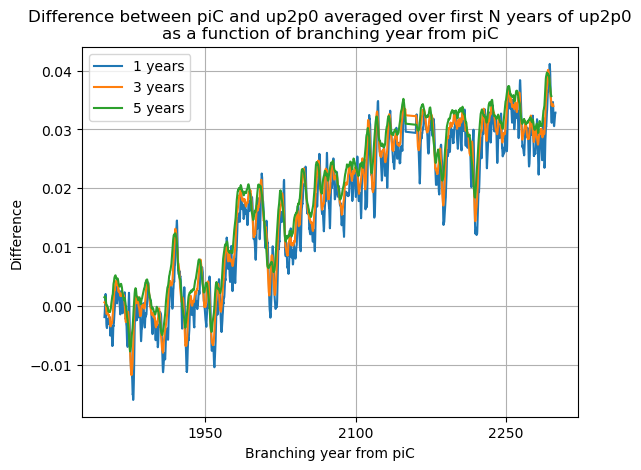

In [147]:
for nyears in [1,3,5]:
    absdiffs = []
    times = []

    for i in range(0, 5280 - int(nyears * 12)):
        piC = global_stats['esm-piControl'].zos_global_mean.isel(
            time=slice(i, i + int(nyears * 12))
        )

        rup = global_stats['esm-up2p0'].zos_global_mean.isel(
            time=slice(0, int(nyears * 12))
        )

        absdiffs.append(np.mean(rup.values - piC.values))
        times.append(piC.time.values[0])

    plt.plot(times, absdiffs, label=f'{nyears} years')

plt.grid()
plt.legend()
plt.ylabel('Difference')
plt.title('Difference between piC and up2p0 averaged over first N years of up2p0\nas a function of branching year from piC')
plt.xlabel('Branching year from piC')
plt.show()

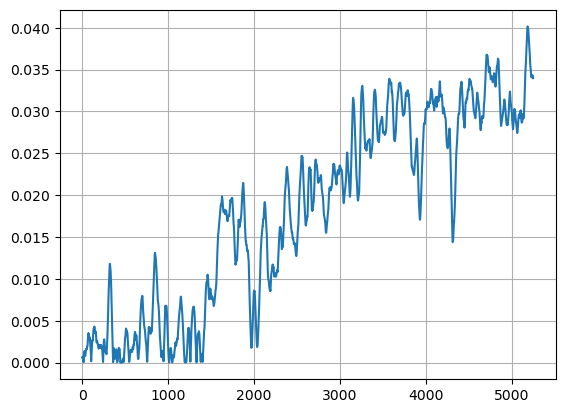

In [134]:
plt.grid()

... plotting esm-piControl ...
... plotting esm-up2p0 ...
... plotting esm-up2p0-gwl2p0 ...
... plotting esm-up2p0-gwl4p0 ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0 ...


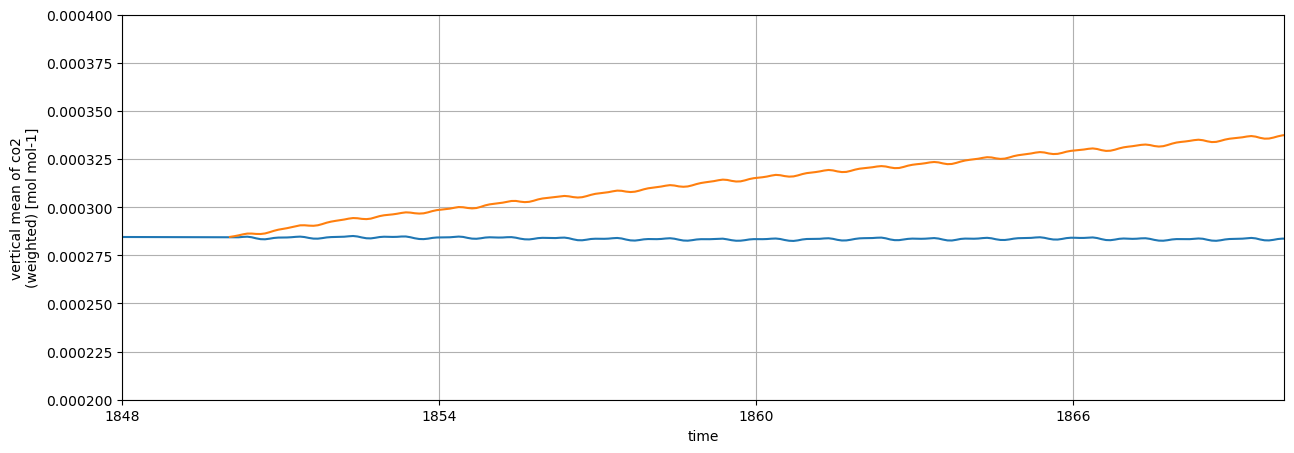

In [35]:
fig, ax = plt.subplots(figsize=(15,5))
for key in global_stats.keys():
    print(f'... plotting {key} ...')
    global_stats[key][namer].plot(ax=ax)
plt.xlim(
    cftime.DatetimeGregorian(1848, 1, 1),
    cftime.DatetimeGregorian(1870, 1, 1),
)
#plt.xlim(
#    cftime.DatetimeGregorian(1850, 1, 1),
#    cftime.DatetimeGregorian(1865, 1, 1),
#)
#plt.ylim(-3,-2.9)
#plt.ylim(-5.25,-5.19)
plt.ylim(0.0002,0.0004)
#plt.ylim(8.5e14,8.64e14)
plt.grid()
plt.show()

... plotting esm-piControl ...
... plotting esm-up2p0 ...
... plotting esm-up2p0-gwl2p0 ...
... plotting esm-up2p0-gwl4p0 ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0 ...
... plotting esm-piControl ...
... plotting esm-up2p0 ...
... plotting esm-up2p0-gwl2p0 ...
... plotting esm-up2p0-gwl4p0 ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0 ...
... plotting esm-piControl ...
... plotting esm-up2p0 ...
... plotting esm-up2p0-gwl2p0 ...
... plotting esm-up2p0-gwl4p0 ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0 ...
... plotting esm-piControl ...
... plotting esm-up2p0 ...
... plotting esm-up2p0-gwl2p0 ...
... plotting esm-up2p0-gwl4p0 ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-d

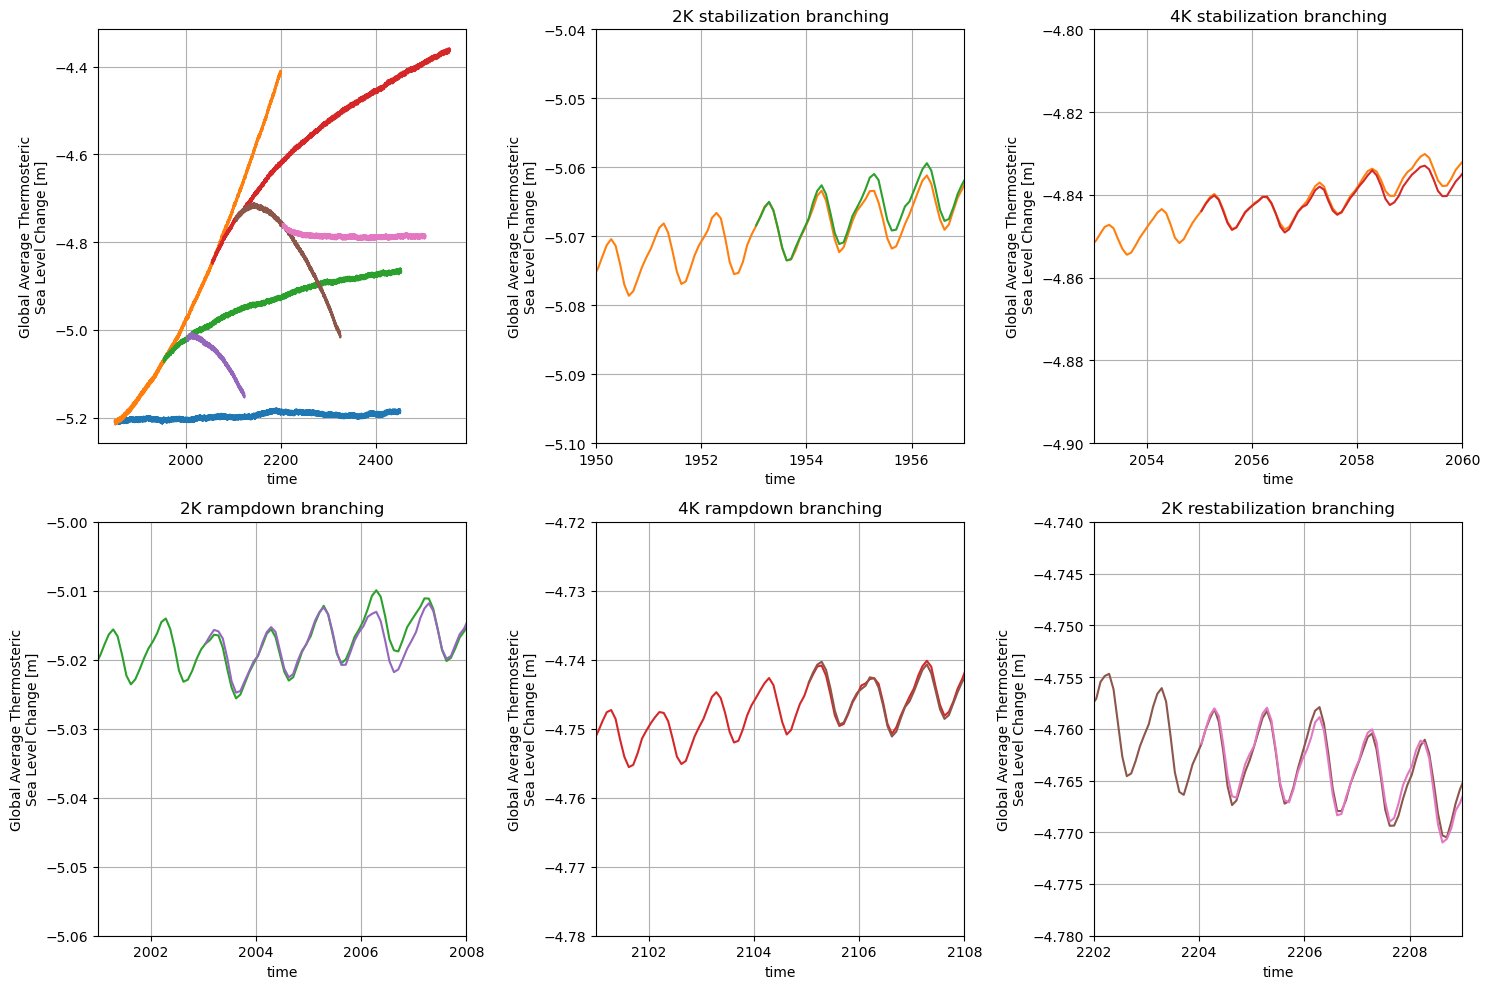

In [34]:
fig, ax = plt.subplots(2,3,figsize=(15,10))
for axi in ax.flat:
    for key in global_stats.keys():
        print(f'... plotting {key} ...')
        global_stats[key][namer].plot(ax=axi)
    axi.grid()

ax[0,1].set_xlim(
    cftime.DatetimeGregorian(1950, 1, 1),
    cftime.DatetimeGregorian(1957, 1, 1),
)
ax[0,1].set_ylim(-5.1,-5.04)
ax[0,1].set_title('2K stabilization branching')

ax[0,2].set_xlim(
    cftime.DatetimeGregorian(2053, 1, 1),
    cftime.DatetimeGregorian(2060, 1, 1),
)
ax[0,2].set_ylim(-4.9,-4.8)
ax[0,2].set_title('4K stabilization branching')


ax[1,0].set_xlim(
    cftime.DatetimeGregorian(2001, 1, 1),
    cftime.DatetimeGregorian(2008, 1, 1),
)
ax[1,0].set_ylim(-5.06,-5)
ax[1,0].set_title('2K rampdown branching')

ax[1,1].set_xlim(
    cftime.DatetimeGregorian(2101, 1, 1),
    cftime.DatetimeGregorian(2108, 1, 1),
)
ax[1,1].set_ylim(-4.78,-4.72)
ax[1,1].set_title('4K rampdown branching')

ax[1,2].set_xlim(
    cftime.DatetimeGregorian(2202, 1, 1),
    cftime.DatetimeGregorian(2209, 1, 1),
)
ax[1,2].set_ylim(-4.78,-4.74)
ax[1,2].set_title('2K restabilization branching')

plt.tight_layout()
plt.show()

not avail
not avail
not avail
not avail
not avail
not avail
not avail


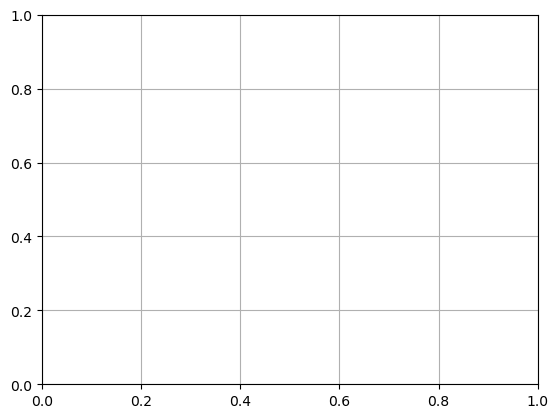

In [17]:
varia = 'zostoga' #'o2' #'zostoga' #'zostoga' #'o2'
stat = 'global_None' #'vertical_integral_global_integral'#'global_None'#'global_None' #'global_mean' #
model = 'MIROC-ES2L' #'ACCESS-ESM1-5'#'GISSE2.1-G-CC2'#'EC-Earth3-ESM-1' #'NorESM2-LM'
member = 'r1i1p1f1' #'001' #'r1i1p1f3' #'r1i2p3f1'
for run in ['esm-piControl','esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0']:
    try:
        ds = xr.open_dataset(f'/home/b/b384080/TIPMIP_carbon_cycle/04_processed_data/global_time_series/{varia}/{model}/{run}/{member}/monthly/{stat}/{varia}_{model}_{run}_{member}_{stat}.nc',use_cftime=True)
        ds[f'{varia}_{stat}'].plot()
    except:
        print('not avail')
#plt.xlim(
#    cftime.DatetimeGregorian(1848, 1, 1),
#    cftime.DatetimeGregorian(1860, 1, 1),
#)
#plt.ylim(0.55,0.65)
plt.grid()
plt.show()
    